In [13]:
import numpy as np
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X= data.data
Y=data.target

print("x shape",X.shape)
print("y shape",Y.shape)

x shape (20640, 8)
y shape (20640,)


In [14]:
np.random.seed(9432)

indices = np.random.permutation(X.shape[0])
n=X.shape[0]

training_end=int(0.60 * n)
validate_end=int(0.80 * n)

train_index=indices[:training_end]
val_index=indices[training_end:validate_end]
test_indices=indices[validate_end:]

X_train= X[train_index]
Y_train=Y[train_index]

X_val=X[val_index]
Y_val=Y[val_index]

X_test= X[test_indices]
Y_test=Y[test_indices]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12384, 8)
(4128, 8)
(4128, 8)


In [15]:
train_mean=np.mean(X_train,axis=0)
train_std=np.std(X_train,axis=0)

X_train_norm=(X_train - train_mean)/train_std
X_val_norm=(X_val - train_mean)/train_std
X_test_norm=(X_test - train_mean)/train_std

In [16]:
X_train_aug = np.hstack((np.ones((X_train_norm.shape[0],1)),X_train_norm))
X_val_aug = np.hstack((np.ones((X_val_norm.shape[0],1)),X_val_norm))
X_test_aug = np.hstack((np.ones((X_test_norm.shape[0],1)),X_test_norm))

print(X_train_aug)
print(X_val_aug)
print(X_test_aug)

[[ 1.         -0.44394841 -0.36960534 ... -0.13163419  1.51799212
  -0.22196568]
 [ 1.         -1.29760907 -0.2901664  ... -0.07247205 -0.86389691
   1.54722757]
 [ 1.          0.61060133 -0.44904429 ... -0.08160887 -0.8778806
   0.87443577]
 ...
 [ 1.          2.05581822 -1.24343374 ...  0.08077033 -0.64481905
   0.39102241]
 [ 1.         -0.07298757  1.37805145 ... -0.07219305  1.00059548
  -1.46289278]
 [ 1.          1.05960126 -0.13128851 ... -0.08291363 -0.93381537
   0.80466477]]
[[ 1.         -0.76087413  0.02758938 ... -0.13473047  0.95398317
  -1.25856341]
 [ 1.         -1.41076313 -1.16399479 ... -0.01148846 -0.73338244
   0.64020455]
 [ 1.         -0.51412594 -0.92567796 ...  0.17426362 -1.31137508
   1.22329078]
 ...
 [ 1.          1.21981986 -0.2901664  ...  0.02596025 -0.62617413
   0.43089155]
 [ 1.         -1.00489697  0.34534516 ... -0.1020338   0.53913362
  -0.11232553]
 [ 1.          0.59603123 -0.84623901 ...  0.0192961  -0.76601106
   0.80964841]]
[[ 1.         -1.

In [17]:
Y_train_mean=np.mean(Y_train)
Y_train_std=np.std(Y_train)

Y_train_norm=(Y_train - Y_train_mean)/Y_train_std
Y_val_norm=(Y_val - Y_train_mean)/Y_train_std
Y_test_norm=(Y_test - Y_train_mean)/Y_train_std

In [18]:
def mse(y_true, y_pred):
    error = y_pred - y_true
    return (1 / (2 * len(y_true))) * (error.T @ error)

def compute_gradient(X_batch,Y_batch,weights):
    m= X_batch.shape[0]
    predictions = X_batch @ weights
    gradient = (1/m)* X_batch.T @ (predictions - Y_batch)
    return gradient

In [19]:
def train_mini_batch_gd(X_train_aug,Y_train_norm,X_val_aug,Y_val_norm,learning_rate,batch_size):

    weights=np.zeros(X_train_aug.shape[1])
    learning_rate=0.01
    batch_size=32
    max_epochs=1000
    patience=100
    
    best_weights=weights.copy()
    best_val_mse=np.inf
    best_epoch=0
    patience_counter=0
    
    train_mse_curve=[]
    val_mse_curve=[]
    
    for epoch in range(1 , max_epochs +1):
        indices= np.random.permutation(X_train_aug.shape[0])
        X_shuffled= X_train_aug[indices]
        Y_shuffled=Y_train_norm[indices]
    
        total_loss=0
        total_samples=0
    
        for start in range(0,X_shuffled.shape[0],batch_size):
            end=start + batch_size
            X_batch=X_shuffled[start:end]
            Y_batch=Y_shuffled[start:end]

            predictions = X_batch @ weights
            batch_loss =mse(Y_batch,predictions)
            total_loss += batch_loss * X_batch.shape[0]
            total_samples += X_batch.shape[0]
            
            gradient= compute_gradient(X_batch,Y_batch,weights)
            weights= weights - learning_rate* gradient
    
        epoch_train_mse = total_loss/total_samples
        train_mse_curve.append(epoch_train_mse)
    
        val_predictions= X_val_aug @ weights
        val_mse = mse(Y_val_norm,val_predictions)
        val_mse_curve.append(val_mse)
    
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_weights = weights.copy()
            best_epoch = epoch 
            patience_counter=0
    
        else:
            patience_counter+=1
    
        if patience_counter>=patience:
            print(f"early stopping at epoch {epoch}")
            break

    return best_weights,train_mse_curve,val_mse_curve,best_epoch

In [28]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
batch_size=128

best_weights,train_curve,val_curve,best_epoch = train_mini_batch_gd(X_train_aug,Y_train_norm,X_val_aug,Y_val_norm,learning_rate,batch_size)

print("best epoch: ", best_epoch)
print("best validation mse : ", min(val_curve))

early stopping at epoch 133
best epoch:  33
best validation mse :  0.19526750169261264


In [30]:
task3_results = []

for lr in learning_rates:

    print(f"Running learning rate = {lr}")

    best_weights, train_curve, val_curve, best_epoch = train_mini_batch_gd(
        X_train_aug,
        Y_train_norm,
        X_val_aug,
        Y_val_norm,
        lr,
        batch_size
    )

    best_val_mse = min(val_curve)

    task3_results.append({
        "learning_rate": lr,
        "best_weights": best_weights,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "best_val_mse": best_val_mse,
        "best_epoch": best_epoch
    })

Running learning rate = 1e-05
early stopping at epoch 122
Running learning rate = 0.0001
early stopping at epoch 202
Running learning rate = 0.001
early stopping at epoch 233
Running learning rate = 0.01
early stopping at epoch 184
Running learning rate = 0.1
early stopping at epoch 198
Running learning rate = 1
early stopping at epoch 114
Running learning rate = 10
early stopping at epoch 167


In [31]:
for result in task3_results:
    print(
        f"LR: {result['learning_rate']}, "
        f"Best Val MSE: {result['best_val_mse']:.5f}, "
        f"Best Epoch: {result['best_epoch']}"
    )

LR: 1e-05, Best Val MSE: 0.19549, Best Epoch: 22
LR: 0.0001, Best Val MSE: 0.19527, Best Epoch: 102
LR: 0.001, Best Val MSE: 0.19524, Best Epoch: 133
LR: 0.01, Best Val MSE: 0.19519, Best Epoch: 84
LR: 0.1, Best Val MSE: 0.19525, Best Epoch: 98
LR: 1, Best Val MSE: 0.19545, Best Epoch: 14
LR: 10, Best Val MSE: 0.19522, Best Epoch: 67


In [32]:
best_lr_result = min(
    task3_results,
    key=lambda result: result["best_val_mse"]
)

best_learning_rate = best_lr_result["learning_rate"]

print("Best learning rate:", best_learning_rate)
print("Best validation MSE:", best_lr_result["best_val_mse"])
print("Best epoch:", best_lr_result["best_epoch"])

Best learning rate: 0.01
Best validation MSE: 0.19518844781537
Best epoch: 84


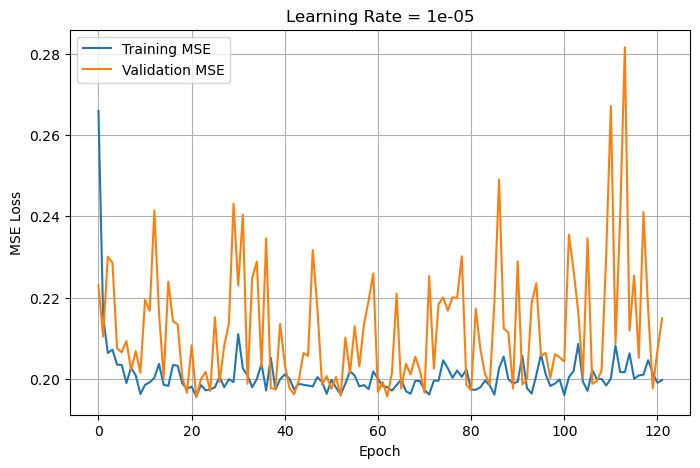

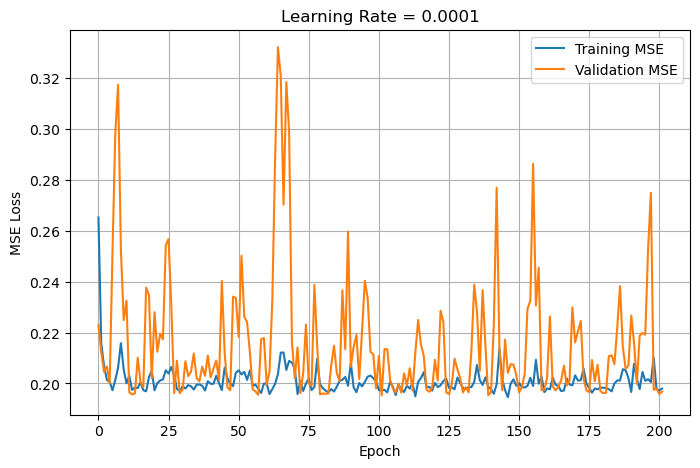

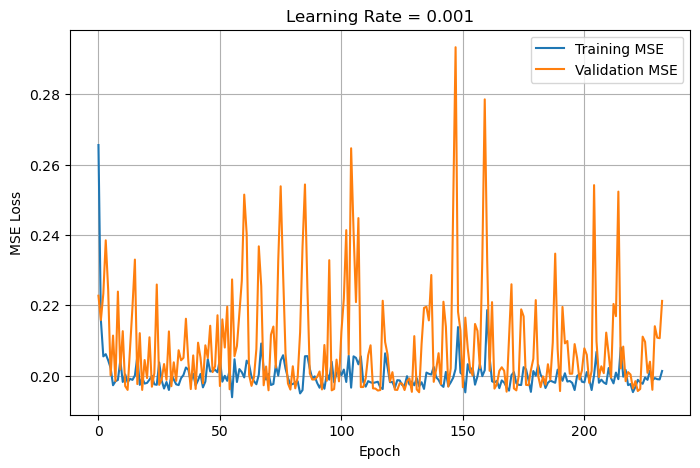

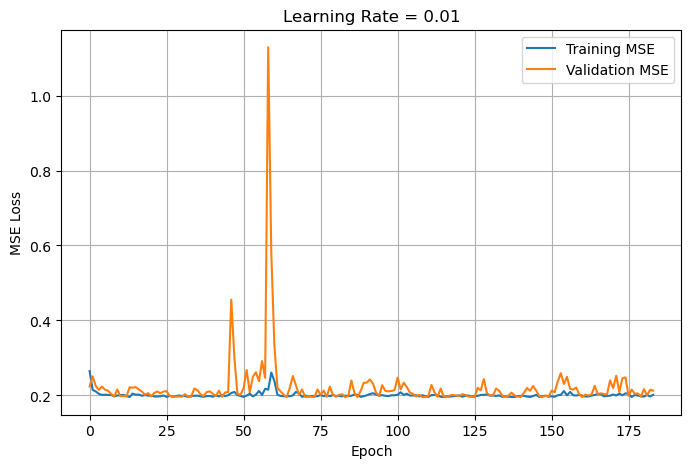

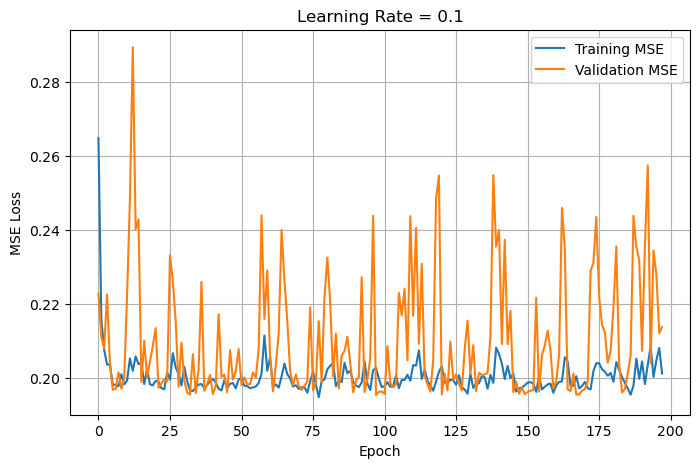

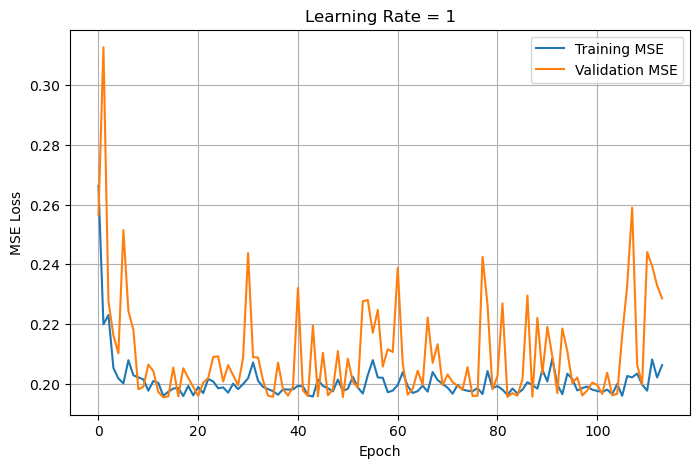

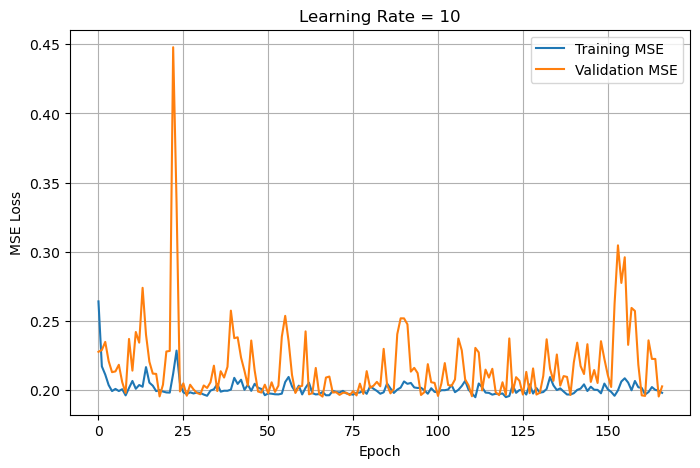

In [33]:
import matplotlib.pyplot as plt

for result in task3_results:

    plt.figure(figsize=(8, 5))

    plt.plot(result["train_curve"], label="Training MSE")
    plt.plot(result["val_curve"], label="Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Rate = {result['learning_rate']}")

    plt.legend()
    plt.grid(True)

    plt.show()

In [34]:
best_learning_rate = 0.01
batch_sizes = [1, 16, 32, 64, 128, 256, X_train_aug.shape[0]]
task4_results = []

for bs in batch_sizes:

    print(f"Running batch size = {bs}")

    best_weights, train_curve, val_curve, best_epoch = train_mini_batch_gd(
        X_train_aug,
        Y_train_norm,
        X_val_aug,
        Y_val_norm,
        best_learning_rate,
        bs
    )

    best_val_mse = min(val_curve)

    task4_results.append({
        "batch_size": bs,
        "best_weights": best_weights,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "best_val_mse": best_val_mse,
        "best_epoch": best_epoch
    })

for result in task4_results:
    print(
        f"Batch Size: {result['batch_size']}, "
        f"Best Val MSE: {result['best_val_mse']:.5f}, "
        f"Best Epoch: {result['best_epoch']}"
    )

Running batch size = 1
early stopping at epoch 226
Running batch size = 16
early stopping at epoch 425
Running batch size = 32
early stopping at epoch 141
Running batch size = 64
early stopping at epoch 129
Running batch size = 128
early stopping at epoch 239
Running batch size = 256
early stopping at epoch 142
Running batch size = 12384
early stopping at epoch 167
Batch Size: 1, Best Val MSE: 0.19518, Best Epoch: 126
Batch Size: 16, Best Val MSE: 0.19523, Best Epoch: 325
Batch Size: 32, Best Val MSE: 0.19533, Best Epoch: 41
Batch Size: 64, Best Val MSE: 0.19516, Best Epoch: 29
Batch Size: 128, Best Val MSE: 0.19514, Best Epoch: 139
Batch Size: 256, Best Val MSE: 0.19516, Best Epoch: 42
Batch Size: 12384, Best Val MSE: 0.19508, Best Epoch: 67


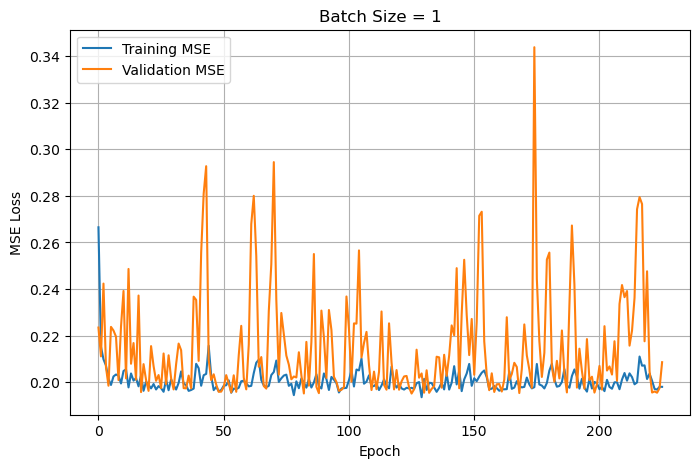

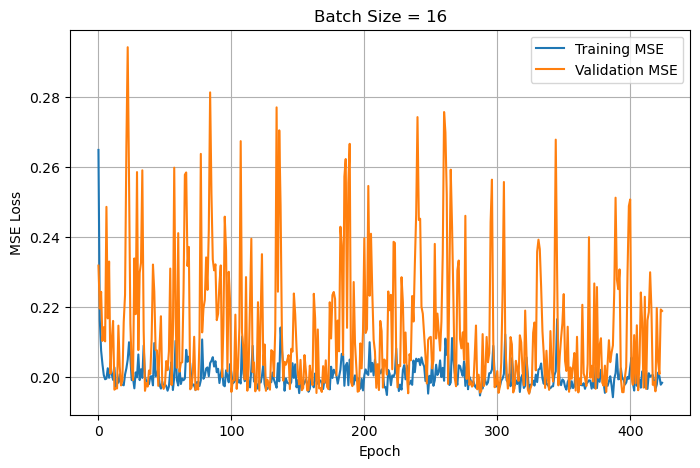

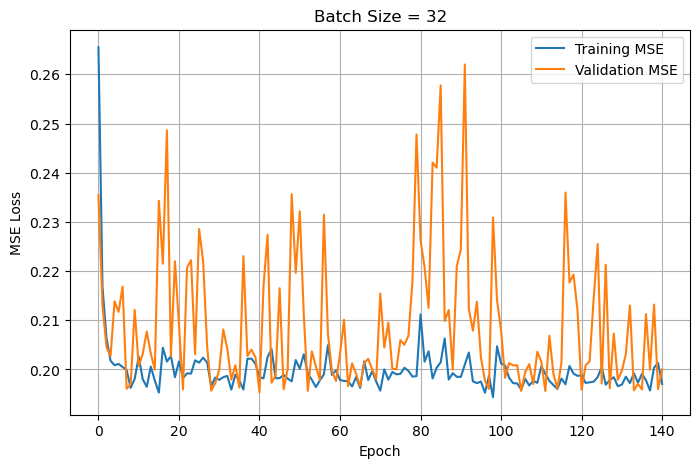

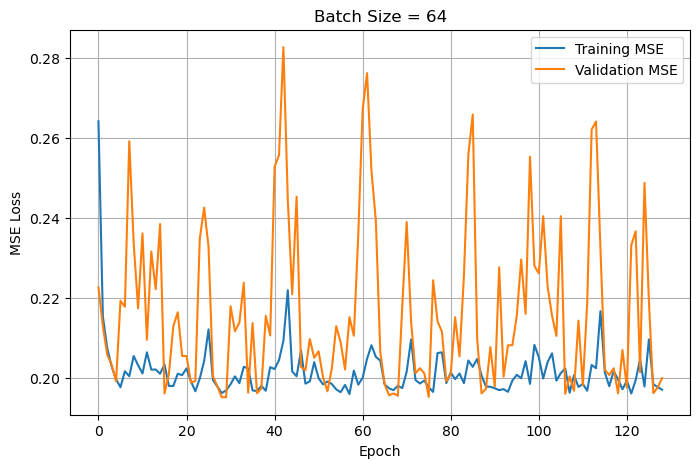

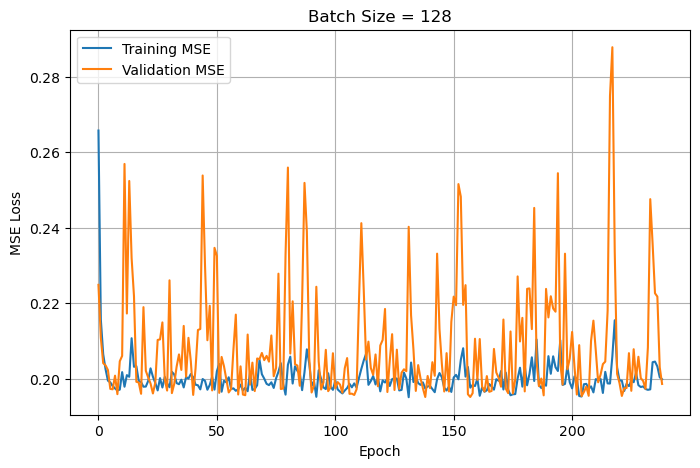

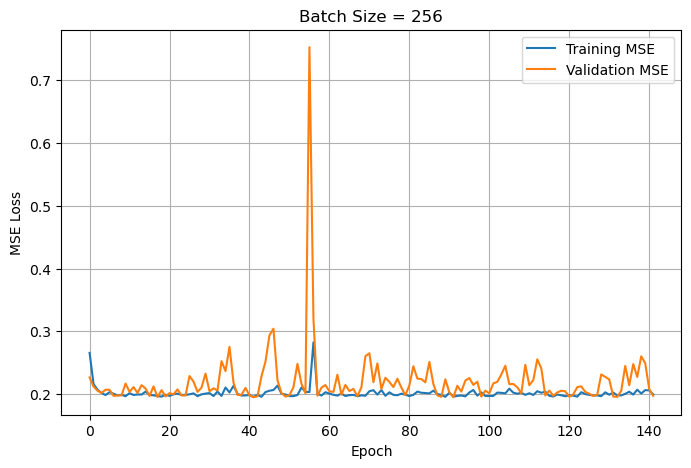

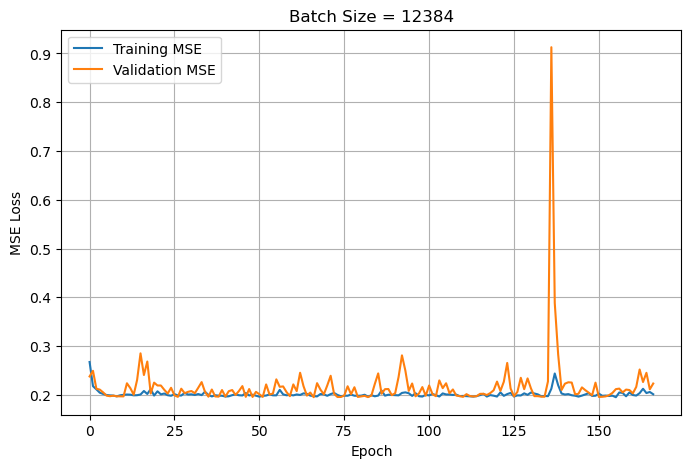

In [35]:
for result in task4_results:

    plt.figure(figsize=(8, 5))

    plt.plot(result["train_curve"], label="Training MSE")
    plt.plot(result["val_curve"], label="Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Batch Size = {result['batch_size']}")

    plt.legend()
    plt.grid(True)

    plt.show()

In [36]:
best_batch_result = min(
    task4_results,
    key=lambda result: result["best_val_mse"]
)

best_batch_size = best_batch_result["batch_size"]

print("Best learning rate:", best_learning_rate)
print("Best batch size:", best_batch_size)
print("Best validation MSE:", best_batch_result["best_val_mse"])
print("Best epoch:", best_batch_result["best_epoch"])

Best learning rate: 0.01
Best batch size: 12384
Best validation MSE: 0.195084089077397
Best epoch: 67


In [37]:
final_weights = best_batch_result["best_weights"]

print("Final model selected")
print("Learning rate:", best_learning_rate)
print("Batch size:", best_batch_size)
print("Best epoch:", best_batch_result["best_epoch"])

train_pred_norm = X_train_aug @ final_weights
val_pred_norm = X_val_aug @ final_weights
test_pred_norm = X_test_aug @ final_weights

train_pred = train_pred_norm * Y_train_std + Y_train_mean
val_pred = val_pred_norm * Y_train_std + Y_train_mean
test_pred = test_pred_norm * Y_train_std + Y_train_mean

Final model selected
Learning rate: 0.01
Batch size: 12384
Best epoch: 67


In [39]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

train_metrics = [
    rmse(Y_train, train_pred),
    mape(Y_train, train_pred),
    mae(Y_train, train_pred),
    r_squared(Y_train, train_pred)
]

val_metrics = [
    rmse(Y_val, val_pred),
    mape(Y_val, val_pred),
    mae(Y_val, val_pred),
    r_squared(Y_val, val_pred)
]

test_metrics = [
    rmse(Y_test, test_pred),
    mape(Y_test, test_pred),
    mae(Y_test, test_pred),
    r_squared(Y_test, test_pred)
]

print(f"{'Dataset':<12} {'RMSE':>10} {'MAPE':>10} {'MAE':>10} {'R-squared':>12}")

print(
    f"{'Training':<12} "
    f"{train_metrics[0]:>10.5f} "
    f"{train_metrics[1]:>10.5f} "
    f"{train_metrics[2]:>10.5f} "
    f"{train_metrics[3]:>12.5f}"
)

print(
    f"{'Validation':<12} "
    f"{val_metrics[0]:>10.5f} "
    f"{val_metrics[1]:>10.5f} "
    f"{val_metrics[2]:>10.5f} "
    f"{val_metrics[3]:>12.5f}"
)

print(
    f"{'Test':<12} "
    f"{test_metrics[0]:>10.5f} "
    f"{test_metrics[1]:>10.5f} "
    f"{test_metrics[2]:>10.5f} "
    f"{test_metrics[3]:>12.5f}"
)

Dataset            RMSE       MAPE        MAE    R-squared
Training        0.72533   31.67046    0.52878      0.60728
Validation      0.72296   31.48806    0.53339      0.59545
Test            0.72789   31.30662    0.53177      0.60630


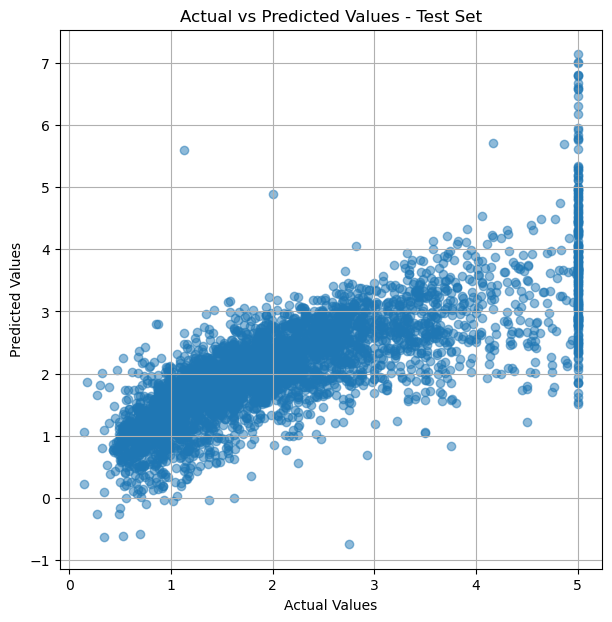

In [41]:
plt.figure(figsize=(7, 7))

plt.scatter(Y_test, test_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Test Set")

plt.grid(True)
plt.show()